<div style="text-align:center; markdown=1">
<span style="font-size:12pt">Tugas Individu</span><br>
<span style="font-size:14pt"><b>Image Classification Menggunakan TensorFlow</b></span><br>
Mata Kuliah Kecerdasar Buatan</div>

<span style="font-size:14pt"><b>Nama Penyusun:</b></span><br>
M. Nadhir Al Ghifary 
22/503570/TK/55030

In [19]:
import argparse
import os
import re
import sys

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


___

### <b>#1: Variabel Global dan Path</b>

Mengatur direktori kerja saat ini (current_dir_path) sebagai path default untuk file model dan gambar. FLAGS digunakan untuk menyimpan parameter dari argumen baris perintah.

In [22]:
FLAGS = None
current_dir_path = os.getcwd()
gambar = 'cropped_panda.jpg'

### <b>#2: Class NodeLookup</b>

Mendefinisikan kelas untuk mengonversi ID node (angka yang mewakili label dalam model) menjadi nama label yang lebih mudah dipahami oleh manusia (misalnya, "panda" dari ID tertentu). Ini memuat file label dari direktori model.

In [11]:
class NodeLookup(object):
    """Converts integer node ID's to human readable labels."""

    def __init__(self, label_lookup_path=None, uid_lookup_path=None):
        if not label_lookup_path:
            label_lookup_path = os.path.join(
                FLAGS.model_dir, 'imagenet_2012_challenge_label_map_proto.pbtxt')
        if not uid_lookup_path:
            uid_lookup_path = os.path.join(
                FLAGS.model_dir, 'imagenet_synset_to_human_label_map.txt')
        self.node_lookup = self.load(label_lookup_path, uid_lookup_path)

    def load(self, label_lookup_path, uid_lookup_path):
        """Loads a human readable English name for each softmax node.

        Args:
          label_lookup_path: string UID to integer node ID.
          uid_lookup_path: string UID to human-readable string.

        Returns:
          dict from integer node ID to human-readable string.
        """
        if not tf.io.gfile.exists(uid_lookup_path):
            raise FileNotFoundError(f'File does not exist {uid_lookup_path}')
        if not tf.io.gfile.exists(label_lookup_path):
            raise FileNotFoundError(f'File does not exist {label_lookup_path}')

        # Loads mapping from string UID to human-readable string
        proto_as_ascii_lines = tf.io.gfile.GFile(uid_lookup_path).readlines()
        uid_to_human = {}
        p = re.compile(r'[n\d]*[ \S,]*')
        for line in proto_as_ascii_lines:
            parsed_items = p.findall(line)
            uid = parsed_items[0]
            human_string = parsed_items[2]
            uid_to_human[uid] = human_string

        # Loads mapping from string UID to integer node ID
        node_id_to_uid = {}
        proto_as_ascii = tf.io.gfile.GFile(label_lookup_path).readlines()
        for line in proto_as_ascii:
            if line.startswith('  target_class:'):
                target_class = int(line.split(': ')[1])
            if line.startswith('  target_class_string:'):
                target_class_string = line.split(': ')[1]
                node_id_to_uid[target_class] = target_class_string[1:-2]

        # Final mapping of integer node ID to human-readable string
        node_id_to_name = {}
        for key, val in node_id_to_uid.items():
            if val not in uid_to_human:
                raise ValueError(f'Failed to locate: {val}')
            name = uid_to_human[val]
            node_id_to_name[key] = name

        return node_id_to_name

    def id_to_string(self, node_id):
        if node_id not in self.node_lookup:
            return ''
        return self.node_lookup[node_id]

### <b>#3: Fungsi create_graph</b>

Memuat dan membangun grafik TensorFlow dari file model classify_image_graph_def.pb. Grafik ini adalah representasi komputasi jaringan saraf.

In [14]:
def create_graph():
    """Creates a graph from saved GraphDef file."""
    with tf.io.gfile.GFile(
            os.path.join(FLAGS.model_dir, 'classify_image_graph_def.pb'), 'rb') as f:
        graph_def = tf.compat.v1.GraphDef()
        graph_def.ParseFromString(f.read())
        tf.import_graph_def(graph_def, name='')

### <b>#4: Fungsi run_inference_on_image</b>

Menggunakan grafik TensorFlow untuk memprediksi label pada gambar tertentu. Hasil prediksi diurutkan dan diterjemahkan ke label manusia menggunakan NodeLookup.

In [15]:
def run_inference_on_image(image):
    """Runs inference on an image.

    Args:
      image: Image file name.

    Returns:
      Nothing
    """
    if not tf.io.gfile.exists(image):
        raise FileNotFoundError(f'File does not exist {image}')
    image_data = tf.io.gfile.GFile(image, 'rb').read()

    # Create the graph
    create_graph()

    # Start a session in TensorFlow 2.x (using tf.compat.v1.Session)
    with tf.compat.v1.Session() as sess:
        # Useful tensors in the graph:
        # 'softmax:0': A tensor containing the normalized prediction
        # 'DecodeJpeg/contents:0': Input JPEG encoding of the image.
        softmax_tensor = sess.graph.get_tensor_by_name('softmax:0')
        predictions = sess.run(softmax_tensor, {'DecodeJpeg/contents:0': image_data})
        predictions = np.squeeze(predictions)

        # Create node ID --> English string lookup
        node_lookup = NodeLookup()

        top_k = predictions.argsort()[-FLAGS.num_top_predictions:][::-1]
        for node_id in top_k:
            human_string = node_lookup.id_to_string(node_id)
            score = predictions[node_id]
            print(f'{human_string} (score = {score:.5f})')


### <b>#5: Fungsi main</b>

Fungsi utama yang menentukan gambar input (default: cropped_panda.jpg) dan menjalankan inferensi pada gambar tersebut menggunakan fungsi run_inference_on_image.

In [23]:
def main(_):
    image = (FLAGS.image_file if FLAGS.image_file else
             os.path.join(FLAGS.model_dir, gambar))
    run_inference_on_image(image)

### <b>#6: Menampilkan Gambar yang Dideteksi</b>

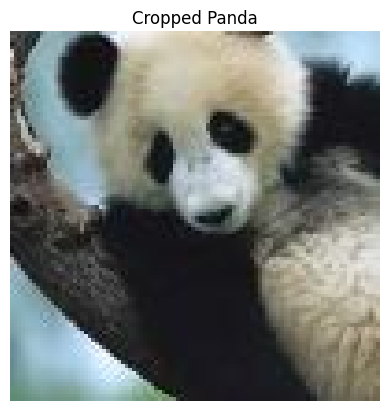

In [24]:
image_path = image_path = os.path.join(current_dir_path, 'inception', gambar)
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')  # Hilangkan axis untuk tampilan lebih bersih
plt.title("Cropped Panda")  # Judul gambar
plt.show()

### <b>#6: Entry Point</b>

Mengatur argumen baris perintah, seperti lokasi model (model_dir) dan file gambar (image_file). Kemudian memanggil fungsi main() untuk memulai proses. Memastikan TensorFlow berjalan dalam mode kompatibilitas untuk kode TensorFlow 1.x.

In [25]:
if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument(
        '--model_dir',
        type=str,
        default=current_dir_path + '/inception',
        help="""\
        Path to classify_image_graph_def.pb,
        imagenet_synset_to_human_label_map.txt, and
        imagenet_2012_challenge_label_map_proto.pbtxt.\\
        """
    )
    parser.add_argument(
        '--image_file',
        type=str,
        default='',
        help='Absolute path to image file.'
    )
    parser.add_argument(
        '--num_top_predictions',
        type=int,
        default=5,
        help='Display this many predictions.'
    )
    FLAGS, unparsed = parser.parse_known_args()

    # Disable eager execution for compatibility
    tf.compat.v1.disable_eager_execution()
    main(None)

giant panda, panda, panda bear, coon bear, Ailuropoda melanoleuca (score = 0.89107)
indri, indris, Indri indri, Indri brevicaudatus (score = 0.00779)
lesser panda, red panda, panda, bear cat, cat bear, Ailurus fulgens (score = 0.00296)
custard apple (score = 0.00147)
earthstar (score = 0.00117)
